<a href="https://colab.research.google.com/github/Leticiavalcan/Leticiavalcan/blob/main/Projeto_case_Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analise de dados AIRBNB


* Pergunta de negócio: Faça uma análise exploratória de dados com a base de dados do Airbnb e indique possíveis oportunidades e/ou ameaças para o empreendimento.

Aluna: Leticia Cavalcante

#Requisitos

* Nível - Tratamento e Análise
Verificar todos os passos da estratégia de análise geral de análise de dados;
Executar o que for necessário;
* Todos os passos devem ser comentados;
Realizar no mínimo 3 análises apenas numéricas;
* Realizar plotagens para no mínimo 3 análises;
* Chegar a uma conclusão de sua análise;
Nivel Infra
* O Dataset deve ser salvo em ambiente local  (Google Drive) - (bruto e tratado)

#Legenda de Dados:
* realSum: preço total
* room_type: tipo de quarto oferecido
* room_shared: se o quarto é compartilhado ou não
* room_private: se o quarto é privativo ou não
* person_capacity: número máximo de pessoas permitidas na propriedade
* host_is_superhost: se o host é ou não um superhost
* multi: tem vários quartos ou não
* biz: seja para uso comercial ou familiar
cleanliness_rating: Classificação de limpeza
* guest_satisfaction_overall: satisfação geral do hóspede
* bedrooms: número de quartos
* dist: a distância do centro da cidade
* metro_dist: a distância da estação de  metrô mais próxima
* lng: Longitude
lat: Latitude

In [3]:
#Instalação de pacotes
!pip install gcsfs
!pip install pandera

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.4/152.4 kB 12.7 MB/s eta 0:00:00


In [4]:
# Abertura de bibliotecas
import os                              # Importar a biblioteca "os" para interagir com o sistema operacional
import pandas as pd                    # Importar a biblioteca "pandas" e atribuir um alias "pd"
import numpy as np                     # O numpy é uma biblioteca popular para computação numérica em Python, fornecendo suporte para matrizes multidimensionais, funções matemáticas avançadas e manipulação eficiente de dados numéricos
import pandera as pa                   # O pandera é uma biblioteca que adiciona recursos de validação de dados ao pandas, permitindo a definição de esquemas e regras para verificar a qualidade e integridade dos dados.
from  google.cloud import storage      # Esse módulo fornece funcionalidades para interagir com o serviço de armazenamento em nuvem do Google Cloud Platform (GCP)

In [5]:
# Ignorar avisos
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Configuração da quantidade de colunas para aparecer em um DataFrame
pd.set_option('display.max_columns',100)

#Extração

In [ ]:
# Comando de abertura para Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Extração por Google Drive
#path= '/content/drive/MyDrive/airbnb_bruto.csv'


In [ ]:
#df = pd.read_csv(path)
#dfback = df.copy()

In [76]:
#Google Cloud
# CONFIGURANDO DA CHAVE DE SEGURANCA - ACESSO O PROJETO
serviceAccount = '/content/proven-electron-389812-3983cf8694b6.json'
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = serviceAccount

In [77]:
# Configurações Google Cloud Storage - ACESSO AO BUCKET
client = storage.Client()
bucket = client.get_bucket('projetos_aula')
bucket.blob('airbnb_bruto.csv')
path = 'gs://projetos_aula/arquivos airbnb/airbnb_bruto.csv'

In [78]:
# Abertura da base de dados e cópia de segurança (bucket)
df = pd.read_csv(path)
dfback = df.copy()

#Pré analise

In [79]:
df

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,1098,2486.115342,Entire home/apt,False,False,2.0,False,0,0,10.0,100.0,1,2.375833,1.436054,181.198355,9.594573,225.304203,15.699521,4.85869,52.37677
1099,1099,233.637194,Private room,False,True,2.0,False,1,0,10.0,90.0,1,4.719736,0.322263,108.024880,5.719989,134.775277,9.391335,4.83611,52.34910
1100,1100,317.062311,Private room,False,True,2.0,False,1,0,10.0,92.0,1,0.598355,0.751993,440.476515,23.323524,625.947562,43.616927,4.88897,52.37798
1101,1101,1812.855904,Entire home/apt,False,False,4.0,False,0,0,8.0,84.0,5,1.943020,0.388532,257.948105,13.658524,336.589237,23.454022,4.90688,52.35794


In [80]:
df.dtypes

Unnamed: 0                      int64
realSum                       float64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
dtype: object

#Transformação

In [81]:
df.drop(['attr_index',
          'attr_index_norm',
          'rest_index',
          'rest_index_norm',
          ],
          axis = 1,
          inplace=True)

In [82]:
df

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,lng,lat
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,4.90569,52.41772
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,4.90005,52.37432
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,4.97512,52.36103
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,4.89417,52.37663
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,4.90051,52.37508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,1098,2486.115342,Entire home/apt,False,False,2.0,False,0,0,10.0,100.0,1,2.375833,1.436054,4.85869,52.37677
1099,1099,233.637194,Private room,False,True,2.0,False,1,0,10.0,90.0,1,4.719736,0.322263,4.83611,52.34910
1100,1100,317.062311,Private room,False,True,2.0,False,1,0,10.0,92.0,1,0.598355,0.751993,4.88897,52.37798
1101,1101,1812.855904,Entire home/apt,False,False,4.0,False,0,0,8.0,84.0,5,1.943020,0.388532,4.90688,52.35794


In [87]:
# Metodo rename voltado apenas para as colunas
df.rename(columns={'realSum':'preco_total','room_type':'tipo_quarto','room_shared':'compartilhado','person_capacity':'capacidade','bedrooms':'qnt_quartos','cleanliness_rating':'nota_limpeza','host_is_superhost':'superhost','guest_satisfaction_overall':'satisfacao','dist':'distancia_centro','metro_dist':'distancia_metro','lat':'latitude','lng':'longitude'})


,Unnamed: 0,preco_total,tipo_quarto,compartilhado,room_private,capacidade,superhost,multi,biz,nota_limpeza,satisfacao,qnt_quartos,distancia_centro,distancia_metro,longitude,latitude
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,4.90569,52.41772
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,4.90005,52.37432
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,4.97512,52.36103
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,4.89417,52.37663
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,4.90051,52.37508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,1098,2486.115342,Entire home/apt,False,False,2.0,False,0,0,10.0,100.0,1,2.375833,1.436054,4.85869,52.37677
1099,1099,233.637194,Private room,False,True,2.0,False,1,0,10.0,90.0,1,4.719736,0.322263,4.83611,52.34910
1100,1100,317.062311,Private room,False,True,2.0,False,1,0,10.0,92.0,1,0.598355,0.751993,4.88897,52.37798
1101,1101,1812.855904,Entire home/apt,False,False,4.0,False,0,0,8.0,84.0,5,1.943020,0.388532,4.90688,52.35794


In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1103 non-null   int64  
 1   realSum                     1103 non-null   float64
 2   room_type                   1103 non-null   object 
 3   room_shared                 1103 non-null   bool   
 4   room_private                1103 non-null   bool   
 5   person_capacity             1103 non-null   float64
 6   host_is_superhost           1103 non-null   bool   
 7   multi                       1103 non-null   int64  
 8   biz                         1103 non-null   int64  
 9   cleanliness_rating          1103 non-null   float64
 10  guest_satisfaction_overall  1103 non-null   float64
 11  bedrooms                    1103 non-null   int64  
 12  dist                        1103 non-null   float64
 13  metro_dist                  1103 

In [100]:
 # Tipos de quarto
sorted(pd.unique(df['room_type']))

['casa inteira/apto', 'quarto compartilhado', 'quarto privado']

In [93]:
df

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,lng,lat
0,0,194.033698,quarto privado,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,4.90569,52.41772
1,1,344.245776,quarto privado,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,4.90005,52.37432
2,2,264.101422,quarto privado,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,4.97512,52.36103
3,3,433.529398,quarto privado,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,4.89417,52.37663
4,4,485.552926,quarto privado,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,4.90051,52.37508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,1098,2486.115342,casa inteira/apto,False,False,2.0,False,0,0,10.0,100.0,1,2.375833,1.436054,4.85869,52.37677
1099,1099,233.637194,quarto privado,False,True,2.0,False,1,0,10.0,90.0,1,4.719736,0.322263,4.83611,52.34910
1100,1100,317.062311,quarto privado,False,True,2.0,False,1,0,10.0,92.0,1,0.598355,0.751993,4.88897,52.37798
1101,1101,1812.855904,casa inteira/apto,False,False,4.0,False,0,0,8.0,84.0,5,1.943020,0.388532,4.90688,52.35794


In [101]:
#Substituindo e traduzindo valores nas colunas
df.loc[df.room_type == 'Entire home/apt', ['room_type']] = 'casa inteira/apto'
df.loc[df.room_type == 'Private room', ['room_type']] = 'quarto privado'
df.loc[df.room_type == 'Shared room', ['room_type']] = 'quarto compartilhado'


In [102]:
df

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,lng,lat
0,0,194.033698,quarto privado,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,4.90569,52.41772
1,1,344.245776,quarto privado,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,4.90005,52.37432
2,2,264.101422,quarto privado,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,4.97512,52.36103
3,3,433.529398,quarto privado,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,4.89417,52.37663
4,4,485.552926,quarto privado,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,4.90051,52.37508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,1098,2486.115342,casa inteira/apto,False,False,2.0,False,0,0,10.0,100.0,1,2.375833,1.436054,4.85869,52.37677
1099,1099,233.637194,quarto privado,False,True,2.0,False,1,0,10.0,90.0,1,4.719736,0.322263,4.83611,52.34910
1100,1100,317.062311,quarto privado,False,True,2.0,False,1,0,10.0,92.0,1,0.598355,0.751993,4.88897,52.37798
1101,1101,1812.855904,casa inteira/apto,False,False,4.0,False,0,0,8.0,84.0,5,1.943020,0.388532,4.90688,52.35794


#Filtragem

In [103]:
df.dtypes

Unnamed: 0                      int64
realSum                       float64
room_type                      object
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
lng                           float64
lat                           float64
dtype: object

In [104]:
#Verificando dados ausentes
df.isna().sum()

Unnamed: 0                    0
realSum                       0
room_type                     0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
lng                           0
lat                           0
dtype: int64

#Análise

In [106]:
df.loc[[0,1098,1102], ['room_type', 'realSum','dist','metro_dist']]

,room_type,realSum,dist,metro_dist
0,quarto privado,194.033698,5.022964,2.539380
1098,casa inteira/apto,2486.115342,2.375833,1.436054
1102,quarto compartilhado,258.008577,0.280204,0.516217


In [107]:
data = {'room_type': ['casa inteira/apto','compart_quarto', 'priv_quarto'],
        'realSum': [12486.115342,258.008577,194.033698 ],
        'dist': [2.375833,0.280204,5.022964 ],
         'metro_dist': [1.436054,0.516217,2.539380 ]}

In [108]:
df.describe()

,Unnamed: 0,realSum,person_capacity,multi,biz,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,lng,lat
count,1103.000000,1103.000000,1103.000000,1103.00000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000,1103.000000
mean,551.000000,545.020526,2.792384,0.30825,0.115141,9.461469,94.362647,1.282865,2.841621,1.089439,4.891158,52.364858
std,318.552978,416.974314,1.044151,0.46198,0.319336,0.798201,6.089691,0.740178,2.123245,0.836546,0.038882,0.019467
min,0.000000,128.887118,2.000000,0.00000,0.000000,4.000000,20.000000,0.000000,0.015059,0.036530,4.775500,52.291100
25%,275.500000,309.797764,2.000000,0.00000,0.000000,9.000000,92.000000,1.000000,1.302058,0.462983,4.871000,52.354580
50%,551.000000,430.248635,2.000000,0.00000,0.000000,10.000000,96.000000,1.000000,2.341366,0.856010,4.890010,52.365590
75%,826.500000,657.324303,4.000000,1.00000,0.000000,10.000000,98.000000,2.000000,3.648138,1.510629,4.907315,52.375260
max,1102.000000,7782.907225,6.000000,1.00000,1.000000,10.000000,100.000000,5.000000,11.187100,4.411915,5.010770,52.423480


In [109]:
estatisticas_descritivas = df.groupby('room_type')[['realSum','dist','metro_dist']].describe()
print(estatisticas_descritivas)

                     realSum                                                  \
                       count        mean         std         min         25%   
room_type                                                                      
casa inteira/apto      538.0  733.179099  503.587912  128.887118  454.854358   
quarto compartilhado     6.0  280.973918  103.303270  192.861997  221.275748   
quarto privado         559.0  366.764655  180.288963  143.650552  258.242917   

                                                            dist            \
                             50%         75%          max  count      mean   
room_type                                                                    
casa inteira/apto     625.336864  841.925808  7782.907225  538.0  2.607222   
quarto compartilhado  258.008577  281.032503   479.225740    6.0  3.972579   
quarto privado        319.640053  410.564057  1714.433014  559.0  3.055076   

                                                  

#Plotagens

In [110]:
# Abertura de biblioteca de visualização
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Distribuição dos Preços por Tipo de Quarto')

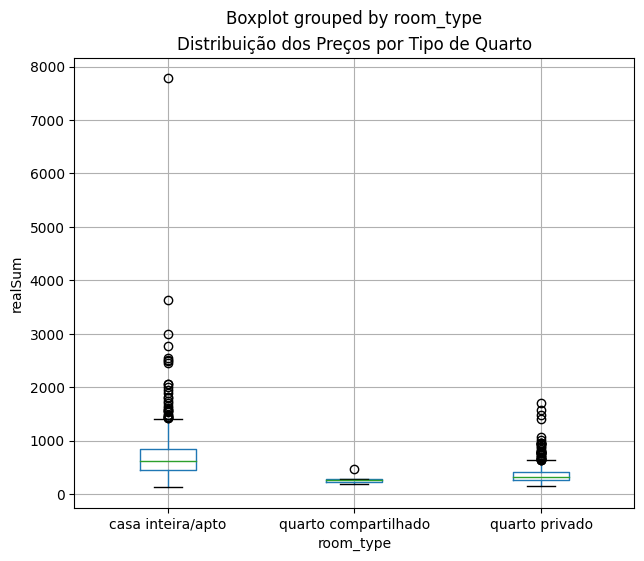

In [112]:
# Boxplot
df.boxplot(column='realSum', by='room_type', figsize=(7, 6))
plt.xlabel('room_type')
plt.ylabel('realSum')
plt.title('Distribuição dos Preços por Tipo de Quarto')

Text(0.5, 1.0, 'Relação entre a Distância da Cidade e o Preço Total')

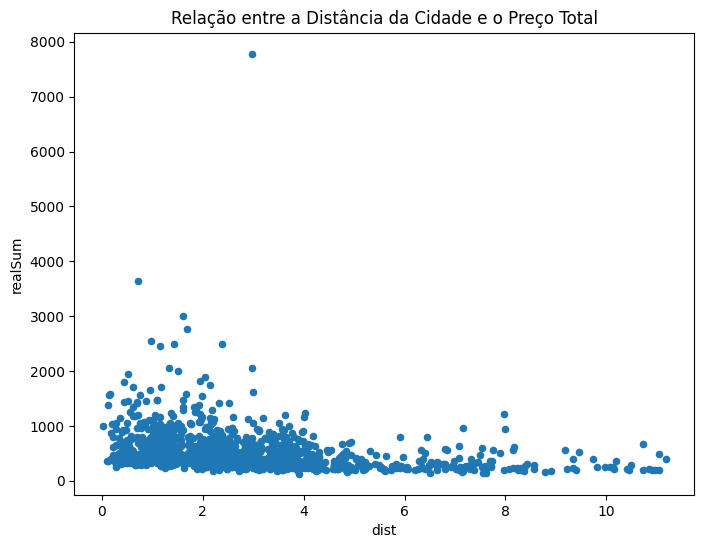

In [113]:
# Gráfico de dispersão - Distância da Cidade vs. Preço Total
df.plot.scatter(x='dist', y='realSum', figsize=(8, 6))
plt.xlabel('dist')
plt.ylabel('realSum')
plt.title('Relação entre a Distância da Cidade e o Preço Total')

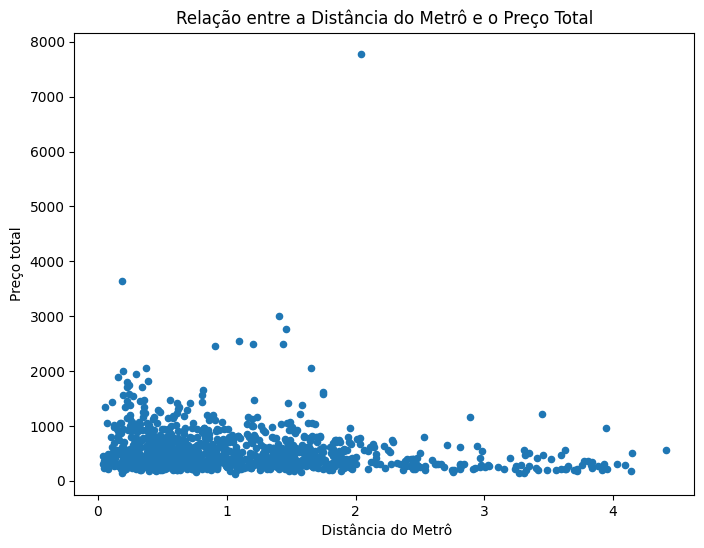

In [115]:
# Gráfico de dispersão - Distância do Metrô vs. Preço Total
df.plot.scatter(x='metro_dist', y='realSum', figsize=(8, 6))
plt.xlabel(' Distância do Metrô')
plt.ylabel('Preço total')
plt.title('Relação entre a Distância do Metrô e o Preço Total')

plt.show()

#Conclusões

Podemos fazer algumas observações sobre o que pode estar afetando o desempenho do hotel

1. Tipo de quarto (room_type): O tipo de quarto parece ter uma influência significativa nos valores das propriedades (realSum). Os quartos "casa inteira/apto" têm um valor médio mais alto (733.17), seguidos pelos quartos "quarto privado" (366.76) e "quarto compartilhado" (280.97). Essa diferença nos valores das propriedades pode indicar uma preferência ou demanda diferente por cada tipo de quarto.

2. Distância média das atrações turísticas (dist): A distância média das atrações turísticas varia para cada tipo de quarto. Os quartos "casa inteira/apto" têm uma distância média de 2.60 km, enquanto os quartos "quarto compartilhado" têm uma distância média de 3.97 km e os quartos "quarto privado" têm uma distância média de 3.05 km. Isso sugere que a localização em relação às atrações turísticas pode ser um fator importante para os hóspedes ao escolherem um tipo de quarto.

3. Distância média do metrô (metro_dist): Da mesma forma que a distância das atrações turísticas, a distância média do metrô também varia para cada tipo de quarto. Os quartos "casa inteira/apto" têm uma distância média do metrô de 1.04 km, os quartos "quarto compartilhado" têm uma distância média de 1.28 km, e os quartos "quarto privado" têm uma distância média de 1.12 km. A proximidade das estações de metrô pode ser um fator relevante para a conveniência e acessibilidade aos hóspedes.

Esses fatores podem afetar o hotel de várias maneiras. Por exemplo, os quartos "casa inteira/apto" podem atrair hóspedes que valorizam a privacidade e o conforto de ter uma acomodação completa, enquanto os quartos "quarto compartilhado" podem ser mais atraentes para hóspedes com orçamentos limitados ou que preferem uma experiência de hospedagem compartilhada. A localização em relação às atrações turísticas e ao transporte público também pode influenciar a escolha dos hóspedes.

